**The Project**: ***Exploratory Data Analysis (EDA) on Restaurant Tips***

*Objective*: Find out who tips more (smokers vs. non-smokers? men vs. women?) and which time of day is most profitable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load sample in-built datset from sns
df = sns.load_dataset('tips')

In [3]:
# see the first 5 col data from dataset
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# last 5 col from dataset
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [5]:
# info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
# descriptive summary of data
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
# check if any null value is present in dataset or not
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [8]:
# if tip is > 15% of total bill then mark that as 1 or else 0
tip_pct = (df['tip'] / df['total_bill']) * 100
df["is_generous"] = np.where(tip_pct > 15, 1, 0)

In [9]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,is_generous
0,16.99,1.01,Female,No,Sun,Dinner,2,0
1,10.34,1.66,Male,No,Sun,Dinner,3,1
2,21.01,3.50,Male,No,Sun,Dinner,3,1
3,23.68,3.31,Male,No,Sun,Dinner,2,0
4,24.59,3.61,Female,No,Sun,Dinner,4,0


In [10]:
# find avg bill for the each day
day_analysis = df.groupby('day')['total_bill'].agg(['mean', 'sum', 'count'])
print(day_analysis)

           mean      sum  count
day                            
Thur  17.682742  1096.33     62
Fri   17.151579   325.88     19
Sat   20.441379  1778.40     87
Sun   21.410000  1627.16     76


C:\Users\NIKHIL\AppData\Local\Temp\ipykernel_8084\293130726.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_analysis = df.groupby('day')['total_bill'].agg(['mean', 'sum', 'count'])


In [11]:
# find generous smoker
generous_smoker = df[(df['is_generous'] == 1) & (df['smoker'] == "Yes")]
print(f"Total Generous Smoker are {len(generous_smoker)}")

Total Generous Smoker are 52


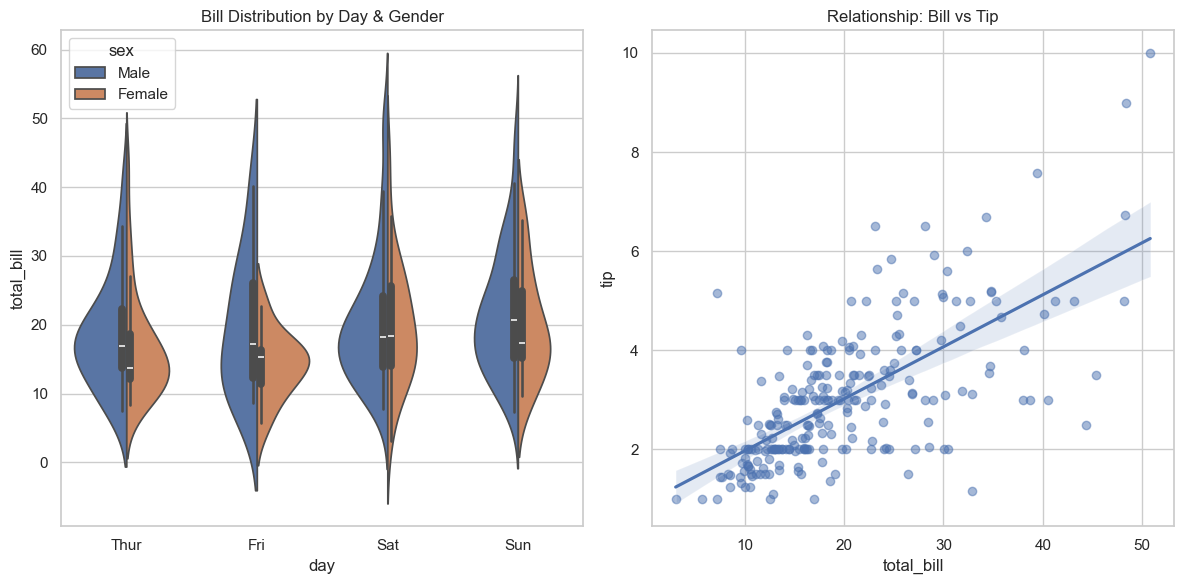

In [12]:
# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Seaborn Violin Plot: Total Bill distribution by Day & Gender
plt.subplot(1, 2, 1)
sns.violinplot(data=df, x='day', y='total_bill', hue='sex', split=True)
plt.title('Bill Distribution by Day & Gender')

# 2. Seaborn Scatter Plot: Total Bill vs Tip with Regression Line
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='total_bill', y='tip', scatter_kws={'alpha':0.5})
plt.title('Relationship: Bill vs Tip')

plt.tight_layout()
plt.show()